# Practical Industrializable PSO Algorithm

**Author:** David Ortega Lozano

**Date:** 28/05/2026

**Subject:** Parallel Programming

**Definition:** Practical exercise for the Parallel Programming course in the 4th year of Computer Engineering. Development of multiple versions of the PSO algorithm in sequential and concurrent programming.


This notebook presents the development, implementation, and evaluation of a Particle Swarm Optimization (PSO) framework focused on parallel programming strategies in Python. To this end, the content of this paper is organized as follows:

- ***1. Introduction***
    - ***1.1. Motivation***
    - ***1.2. Project Objectives***

- ***2. Methodologies***
    - ***2.1 Particle Swarm Optimization Overview***
    - ***2.2. Parallelization strategies***
        - ***2.2.1. Sequential Implementation***
        - ***2.2.2. Threading-Based Parallelization***
        - ***2.2.3. Multiprocessing-Based Parallelization***
        - ***2.2.4. AsyncIO-Based Parallelization***
    - ***2.3. Benchmark Functions***
        - ***2.3.1. Sphere Function***
        - ***2.3.2. Rastrigin Function***
        - ***2.3.3. Rosenbrock Function***
        - ***2.3.4. Ackley Function***
        - ***2.3.5. Logistic Regression Hyperparameter Optimization***
- ***3. Experimentation***
    - ***3.1. Experiment 1: Comparison of Parallelization Strategies Using Benchmark Functions***
    - ***3.2. Experiment 2: Grid search for Rosenbrock benchmark function***
    - ***3.3. Experiment 3: Optimization of the Industrialized Case***
- ***4. Conclusions***

---

## 1. Introduction

### 1.1. Motivation

Optimization problems appear in a wide variety of scientific, industrial, and engineering domains. Many real-world problems require finding the best possible solution among a large set of alternatives while minimizing computational cost and execution time. Traditional optimization techniques often struggle when dealing with highly non-linear, multimodal, or high-dimensional search spaces.

Particle Swarm Optimization (PSO) is a population-based metaheuristic inspired by the collective behavior of biological systems such as bird flocks or fish schools. In PSO, a set of particles explores the search space collaboratively, sharing information about the best solutions found during the optimization process. Due to its simplicity, flexibility, and relatively low computational complexity, PSO has become one of the most widely used swarm intelligence algorithms.

One of the most interesting characteristics of PSO is that particle evaluations are largely independent during each iteration. This property makes the algorithm naturally suitable for concurrent and parallel execution models. However, the actual performance improvements obtained through parallelization strongly depend on the programming model, synchronization strategy, and execution environment.

This project explores the implementation and evaluation of different execution strategies for the PSO algorithm using Python. In particular, the project focuses on analyzing the impact of sequential execution, multithreading,  multiprocessing and async approaches over several benchmark optimization functions and dimensional configurations.

### 1.2. Project Objectives

The main objective of this project is to design and develop a modular and extensible implementation of the Particle Swarm Optimization algorithm while studying the impact of concurrency and parallelism on its performance and convergence behavior.

The specific objectives of the project are:

- Implement a fully functional and modular PSO architecture in Python.

- Develop and compare different execution strategies:
    - Sequential execution
    - Thread-based concurrency
    - Multiprocessing-based parallelization
    - AsyncIO-based concurrency

---

## 2. Methodologies

### 2.1 Particle Swarm Optimization Overview

Particle Swarm Optimization (PSO) is a stochastic optimization algorithm proposed by Kennedy and Eberhart in 1995. The algorithm simulates the collective movement of a swarm of particles searching for the optimal solution in a multidimensional search space.

Each particle represents a candidate solution characterized by a position vector, a velocity vector and a personal best position found so far. Additionally, the swarm maintains a global best position representing the best solution discovered by any particle.

At every iteration, each particle updates its velocity according to three main components: the inertia term (w), the cognitive component (c1) and the social component (C2). The particle then updates its position using the newly computed velocity and evaluates the objective function again.

The velocity update rule is defined as: $$v(t+1) = w * v(t) + c1 * r1 * (pBest - x(t)) + c2 * r2 * (gBest - x(t))$$

Where r1 and r2 are random values, pBest is the particle’s personal best position and gBest is the swarm’s global best position.

The position update rule is: $x(t+1) = x(t) + v(t+1)$

The optimization process continues until a stopping criterion is reached, such as a maximum number of iterations or a sufficiently low error threshold.

---

### 2.2. Parallelization strategies

This project compares four execution strategies for the PSO algorithm, one of which is the sequential version, which is used as the baseline reference, while the remaining implementations aim to explore different forms of concurrency and parallelism in Python.

#### 2.2.1. Sequential Implementation

The sequential version represents the standard execution model of the PSO algorithm. In this approach, particles are updated one after another within each iteration of the swarm optimization process.

For every particle, the algorithm performs the following steps sequentially:

1. Update particle velocity.
2. Update particle position.
3. Evaluate the objective function.
4. Update the particle’s personal best solution.

Finally, when all the particles are updated, it synchronize the swarm’s global best solution.

This implementation establishes the reference behavior and performance of the algorithm. Since all operations are executed in a deterministic order and without synchronization overhead, it serves as the baseline for comparing the remaining strategies.

#### 2.2.2. Threading-Based Parallelization

The threading implementation parallelizes the particle update stage by assigning the computation of each particle to an independent thread. The goal of this strategy is to exploit concurrency while maintaining a shared memory space between all particles of the swarm.

During each iteration:

- A thread is created for each particle.
- Each thread independently updates the particle’s velocity and position and evaluates its fitness.
- Once all threads complete their execution, the global best solution is updated synchronously.

This approach benefits from the lightweight communication model of threads, since all particles share the same memory space. However, Python’s Global Interpreter Lock (GIL) limits true parallel execution of Python bytecode. As a consequence, threading may not improve performance in CPU-bound workloads dominated by Python operations.

Nevertheless, some numerical computations performed using NumPy release the GIL internally, allowing partial parallel execution during vectorized operations.

#### 2.2.3. Multiprocessing-Based Parallelization

The multiprocessing implementation distributes particle computations across multiple independent processes instead of threads. Unlike threading, each process has its own Python interpreter and memory space, avoiding the limitations imposed by the GIL.

In this strategy:

- Particle updates are distributed among 2 worker processes using a process pool.
- Each process independently computes the velocity update, position update, and fitness evaluation of its assigned particle.
- Updated particles are returned to the main process.
- The swarm’s global best solution is synchronized after all processes finish their computation.

This approach enables true parallel execution on multiple CPU cores and is more suitable for CPU-intensive workloads. However, multiprocessing introduces additional overhead due to process creation, inter-process communication (IPC), and object serialization/deserialization (pickling).

Object serialization/deserialization (pickling) and inter-process communication (IPC) introduce significant overhead. Since processes do not share memory, particle objects must be converted into byte streams, transferred between processes, and reconstructed again after computation. For lightweight workloads such as PSO particle updates, this communication cost can become larger than the computation itself, severely reducing performance efficiency.

Since PSO is a stochastic optimization algorithm, small differences in the generation of random numbers and in the execution order among processes can lead to slightly different optimization trajectories, even when deterministic seeds are used. This is important because, during the execution of the algorithm using multiprocessing, the reference to the random numbers generated by the seeds is lost. This could mean that the result is slightly different from that obtained by other strategies.

#### 2.2.4. AsyncIO-Based Parallelization

The AsyncIO implementation uses cooperative concurrency through Python’s asynchronous event loop. Instead of creating multiple threads or processes, particle updates are scheduled as asynchronous tasks that voluntarily yield execution control during runtime.

This approach introduces very little overhead compared to threading or multiprocessing, since no additional processes are created and memory is shared within the same interpreter. However, because PSO is a CPU-bound workload rather than an I/O-bound problem, AsyncIO does not provide true parallel execution and therefore achieves performance very similar to the sequential implementation.

---

### 2.3. Benchmark Functions

To evaluate the behavior and convergence capabilities of the different PSO implementations, four well-known benchmark optimization functions are used.



#### 2.3.1. Sphere Function

The Sphere function is a simple convex optimization problem with a single global minimum located at the origin.

It's characteristics are that it is continuous, convex, unimodal and easy to optimize because it doesn't have any local minimun.

It is commonly used as a baseline benchmark for optimization algorithms.

#### 2.3.2. Rastrigin Function

The Rastrigin function is a highly multimodal function containing many local minima.

It's characteristics are that it is non-convex, highly multimodal, periodic landscape and difficult for a global search, because it has a lot of local minimuns where the particles could get stack.

This function is useful for evaluating exploration capabilities and robustness against local minima.

#### 2.3.3. Rosenbrock Function

The Rosenbrock function, also known as the Banana Function, contains a narrow curved valley leading to the global optimum.

Characteristics:

Non-convex
Narrow optimum region
Difficult convergence behavior

It is commonly used to evaluate the exploitation capability of optimization algorithms.

#### 2.3.4. Ackley Function

The Ackley function is another multimodal benchmark characterized by a nearly flat outer region and many local minima.

Characteristics:

Highly multimodal
Complex search landscape
Challenging convergence dynamics

This function tests the balance between exploration and exploitation.

#### 2.3.5. Logistic Regression Hyperparameter Optimization

To demonstrate the practical applicability of the PSO framework beyond synthetic mathematical benchmarks, a real-world optimization problem based on Logistic Regression was implemented.

In this case, PSO is used to optimize the hyperparameters of a Logistic Regression classifier trained on the Breast Cancer dataset provided by scikit-learn. The optimized parameters include the regularization strength (C), the solver tolerance (tol), and the maximum number of training iterations (max_iter).

Unlike classical benchmark functions, this optimization problem is computationally more expensive because each particle evaluation requires training and validating a machine learning model. This makes the workload more representative of real industrial optimization scenarios.

This use case also allows evaluating how different parallelization strategies behave under heavier CPU-bound workloads, where the computational cost of each task is significantly larger than in standard mathematical functions.

---

## 3. Experimentation

This section describes the experiments conducted as part of the project, presenting and explaining the results obtained.

### 3.1. Experiment 1: Comparison of Parallelization Strategies Using Benchmark Functions

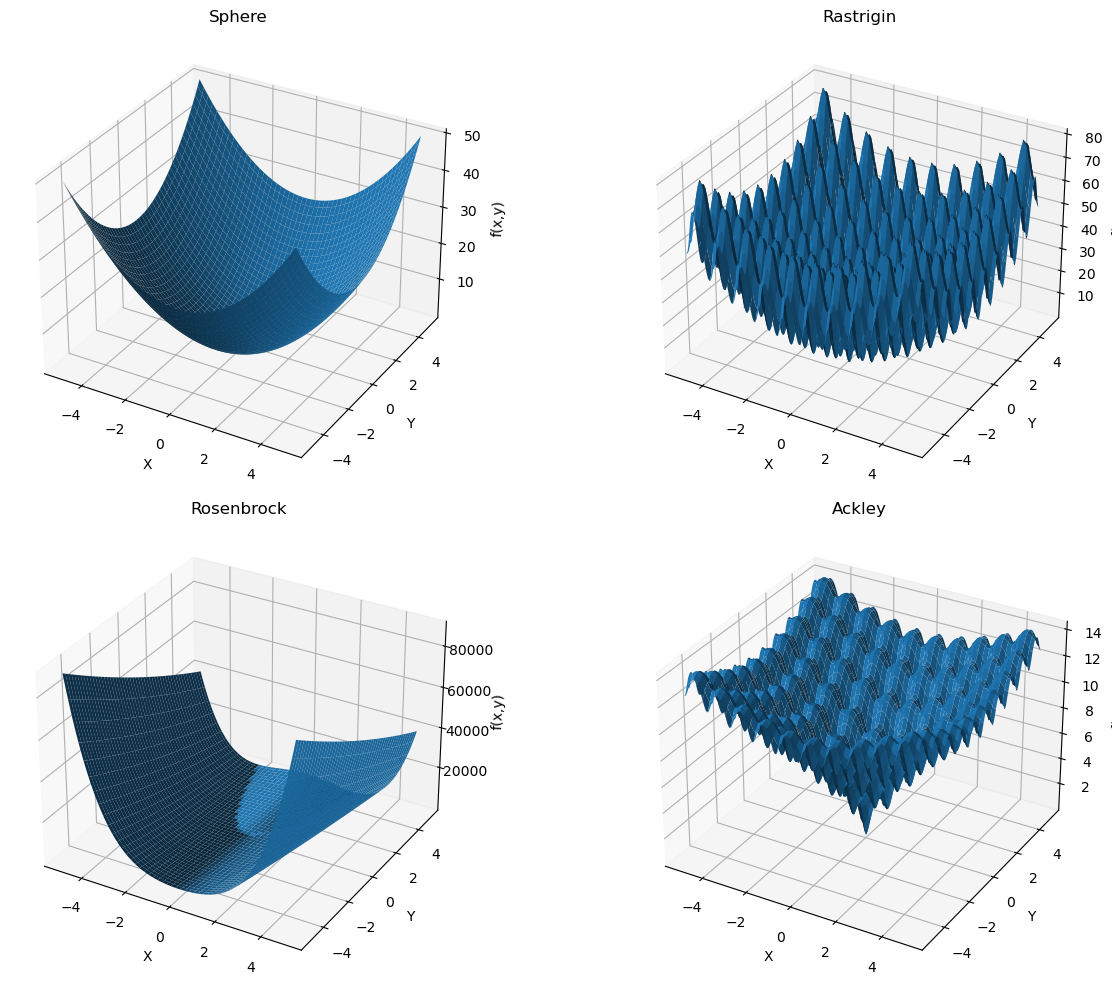

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import os

sys.path.append(os.path.abspath(".."))

from objectives.sphere import sphere_function
from objectives.rosenbrock import rosenbrock_function
from objectives.rastrigin import rastrigin_function
from objectives.ackley import ackley_function

# Grid
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)

X, Y = np.meshgrid(x, y)

# Wrapper functions
sphere = np.vectorize(lambda x, y: sphere_function(np.array([x, y])))
rastrigin = np.vectorize(lambda x, y: rastrigin_function(np.array([x, y])))
rosenbrock = np.vectorize(lambda x, y: rosenbrock_function(np.array([x, y])))
ackley = np.vectorize(lambda x, y: ackley_function(np.array([x, y])))

# Evaluate
Z1 = sphere(X, Y)
Z2 = rastrigin(X, Y)
Z3 = rosenbrock(X, Y)
Z4 = ackley(X, Y)

# Figure
fig = plt.figure(figsize=(14, 10))

functions = [("Sphere", Z1), ("Rastrigin", Z2), ("Rosenbrock", Z3), ("Ackley", Z4)]

for i, (title, Z) in enumerate(functions, start=1):

    ax = fig.add_subplot(2, 2, i, projection='3d')

    ax.plot_surface(X, Y, Z)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("f(x,y)")

plt.tight_layout()
plt.show()

The image above shows a graphical representation of the four functions: Sphere, Rastrigin, Rosenbrock and Ackley. It can be seen that the absolute minimum value of these four functions is 0, which is reached at the point (0,0), except for the Rosenbrock function, which reaches its minimum at the point (1,1).

Next, we will use the four parallelization strategies to determine the absolute minimum of these functions. For this demonstration, we will use two dimensions, but it would be possible to do so with three, ten, or thirty.

In [ ]:
from experiments.exp1 import compare
from viz.charts import plot
import json

with open('config.json', 'r') as f:
    config = json.load(f)

for i in range(len(config["OBJ_FUNC"]) - 1):
    print(f"Results for the {config['OBJ_FUNC'][i]} function:")
    compare(dimensions=2, function_choice=i+1)
    print("\n")

plot()

Results for the Sphere function:
+-----------------+--------------------+------------+--------------------+
|      Method     |   Best Position    | Best Value | Execution Time (s) |
+-----------------+--------------------+------------+--------------------+
|    Sequential   | [-0.1009, -0.0167] |   0.0105   |       0.1987       |
|    Threading    | [-0.1009, -0.0167] |   0.0105   |       1.9313       |
| Multiprocessing | [-0.0728, -0.0342] |   0.0065   |       2.037        |
|     AsyncIO     | [-0.1009, -0.0167] |   0.0105   |       0.1721       |
+-----------------+--------------------+------------+--------------------+


Results for the Rastrigin function:
+-----------------+------------------+------------+--------------------+
|      Method     |  Best Position   | Best Value | Execution Time (s) |
+-----------------+------------------+------------+--------------------+
|    Sequential   | [0.0002, 0.0005] |   0.0001   |       1.0462       |
|    Threading    | [0.0002, 0.0005] 

First, it should be noted that the version of the PSO algorithm developed in this study has two exit strategies: either a maximum of 200 iterations are performed, or the result converges to `0` and a value within the error range specified in the configuration file is obtained, in this case `±0.05`. With these results, in which 200 particles are used in two dimensions, it can be seen that all runs have converged to values within the error range, opting for early termination.

The results obtained show a highly consistent behavior between the sequential, threading, and AsyncIO implementations. For all benchmark functions, these three strategies converged to exactly the same best positions and best values. This behavior is explained by the deterministic initialization of the random seeds used to generate the stochastic coefficients r1 and r2 during the PSO execution. Since these implementations share the same execution flow and memory space, the sequence of random numbers remains identical across executions, leading to equivalent optimization trajectories and final solutions.

The multiprocessing implementation behaves differently. Although it follows the same PSO logic, each worker process executes independently and does not share memory with the parent process. During each iteration, particles are serialized, transferred to worker processes, evaluated independently, and then reconstructed when returned to the main process. As a consequence, the deterministic trace of the random seeds is broken, causing each process to generate slightly different random sequences. This explains why the multiprocessing version converges to different best positions and occasionally achieves slightly better best values than the other strategies.

From a performance perspective, the sequential implementation consistently achieved the best balance between optimization quality and execution time. The threading strategy produced identical optimization results but introduced a significant slowdown due to the Global Interpreter Lock (GIL), which prevents true parallel execution of CPU-bound tasks in Python. The additional synchronization and context-switching overhead made threading considerably less efficient for these workloads.

The multiprocessing approach achieved true parallel execution across CPU cores, but its performance was heavily penalized by process management overhead, inter-process communication (IPC), and object serialization/deserialization (pickling). These costs became particularly noticeable in lightweight objective functions, where the computational effort of evaluating particles is relatively small compared to the overhead required to distribute computations among processes. This explains the substantial increase in execution times observed in functions such as Rastrigin and Ackley.

Finally, the AsyncIO implementation achieved execution times very close to the sequential version. This small diference is caused by the concurrency model employed by AsyncIO. During the optimization loop, each coroutine explicitly yields control to the event loop using `await asyncio.sleep(0)`. Although this instruction does not introduce any actual waiting time, it allows the scheduler to temporarily suspend the current coroutine and switch execution to another pending task. This cooperative task scheduling introduces a small management overhead, which explains why AsyncIO is slightly slower than the pure sequential implementation despite not performing real parallel computation.

Overall, the experiments demonstrate that for low-dimensional and computationally inexpensive optimization problems, the overhead introduced by Python parallelization strategies outweighs their potential benefits. Under these conditions, the sequential implementation remains the most efficient solution, while multiprocessing only becomes potentially advantageous for substantially heavier objective functions where the computational cost per particle is large enough to amortize the IPC and serialization overhead.

The following graphs show the convergence trajectory of these implementation:

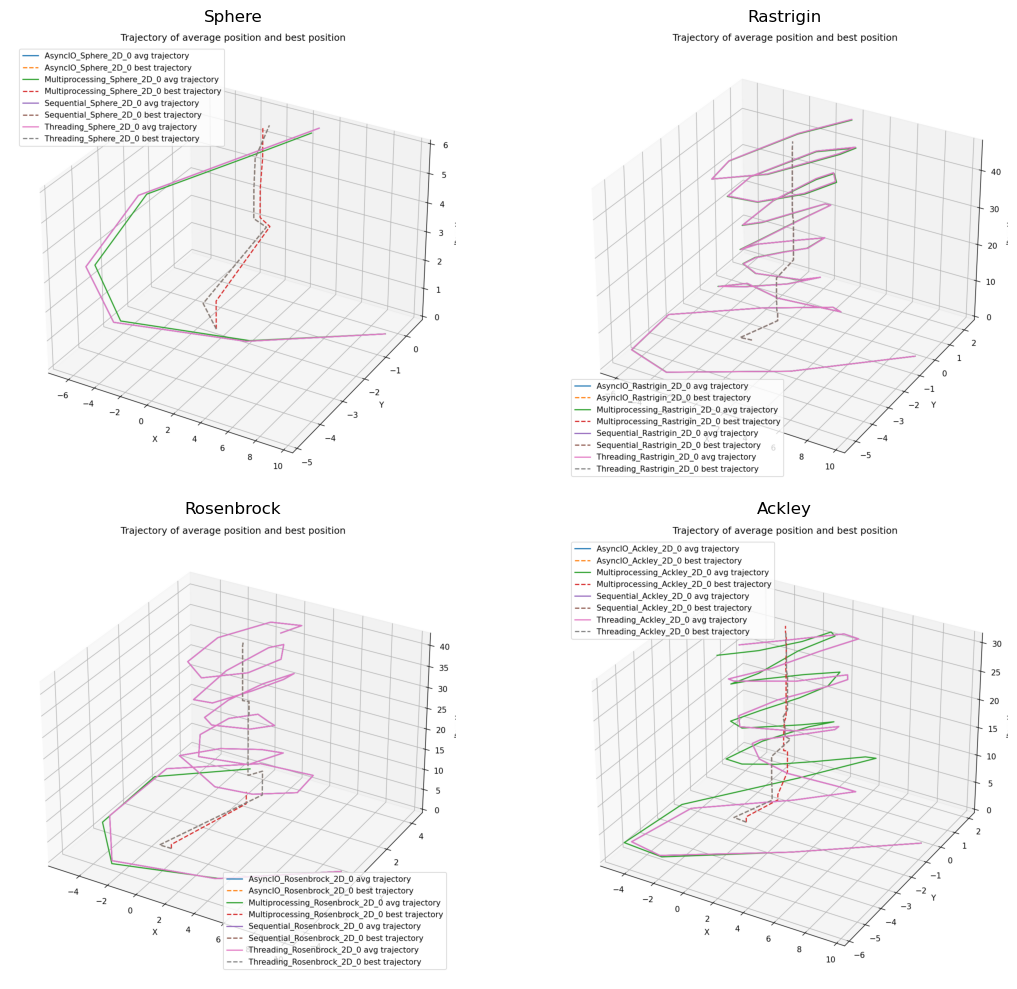

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
img1 = mpimg.imread("viz/0_Sphere_positions_3D.png")
img2 = mpimg.imread("viz/0_Rastrigin_positions_3D.png")
img3 = mpimg.imread("viz/0_Rosenbrock_positions_3D.png")
img4 = mpimg.imread("viz/0_Ackley_positions_3D.png")

# Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot images
axs[0, 0].imshow(img1)
axs[0, 0].set_title("Sphere")
axs[0, 0].axis("off")

axs[0, 1].imshow(img2)
axs[0, 1].set_title("Rastrigin")
axs[0, 1].axis("off")

axs[1, 0].imshow(img3)
axs[1, 0].set_title("Rosenbrock")
axs[1, 0].axis("off")

axs[1, 1].imshow(img4)
axs[1, 1].set_title("Ackley")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

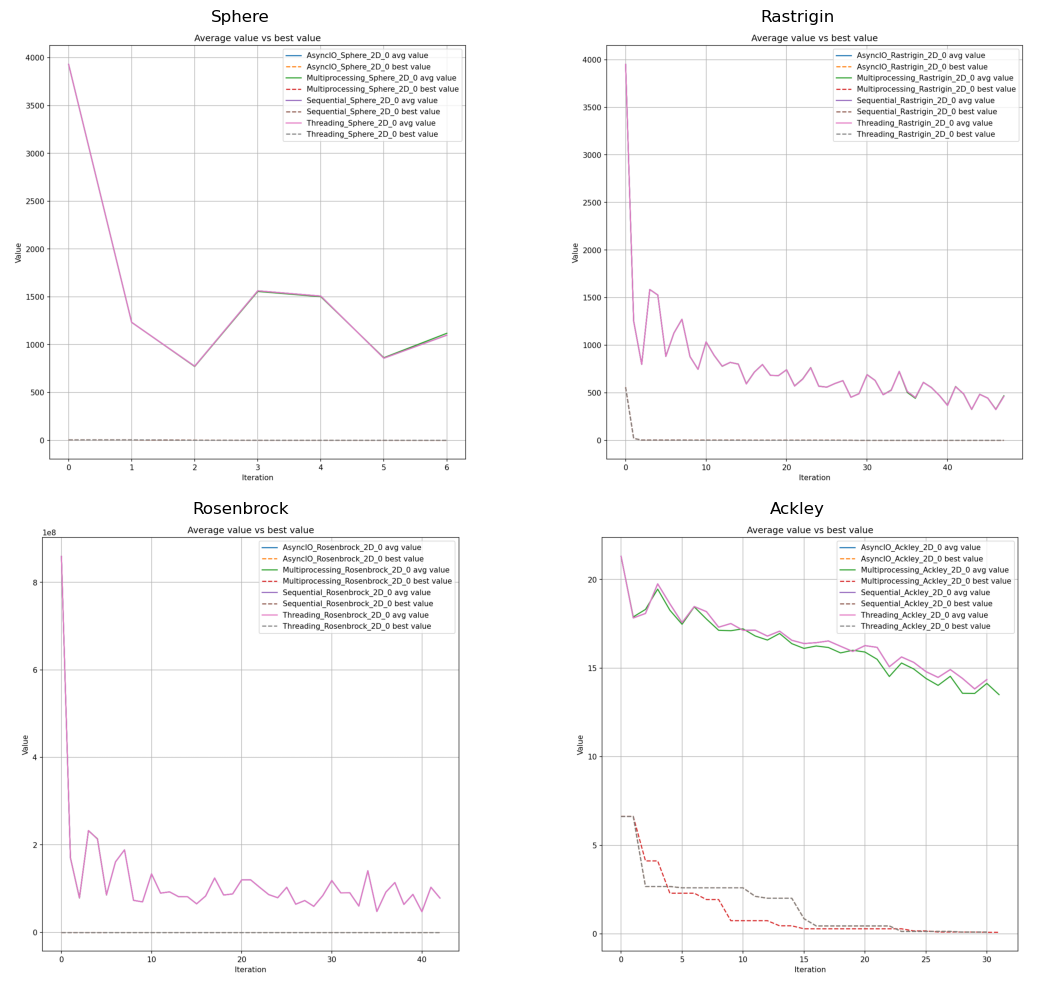

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
img1 = mpimg.imread("viz/0_Sphere_values_2D.png")
img2 = mpimg.imread("viz/0_Rastrigin_values_2D.png")
img3 = mpimg.imread("viz/0_Rosenbrock_values_2D.png")
img4 = mpimg.imread("viz/0_Ackley_values_2D.png")

# Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot images
axs[0, 0].imshow(img1)
axs[0, 0].set_title("Sphere")
axs[0, 0].axis("off")

axs[0, 1].imshow(img2)
axs[0, 1].set_title("Rastrigin")
axs[0, 1].axis("off")

axs[1, 0].imshow(img3)
axs[1, 0].set_title("Rosenbrock")
axs[1, 0].axis("off")

axs[1, 1].imshow(img4)
axs[1, 1].set_title("Ackley")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

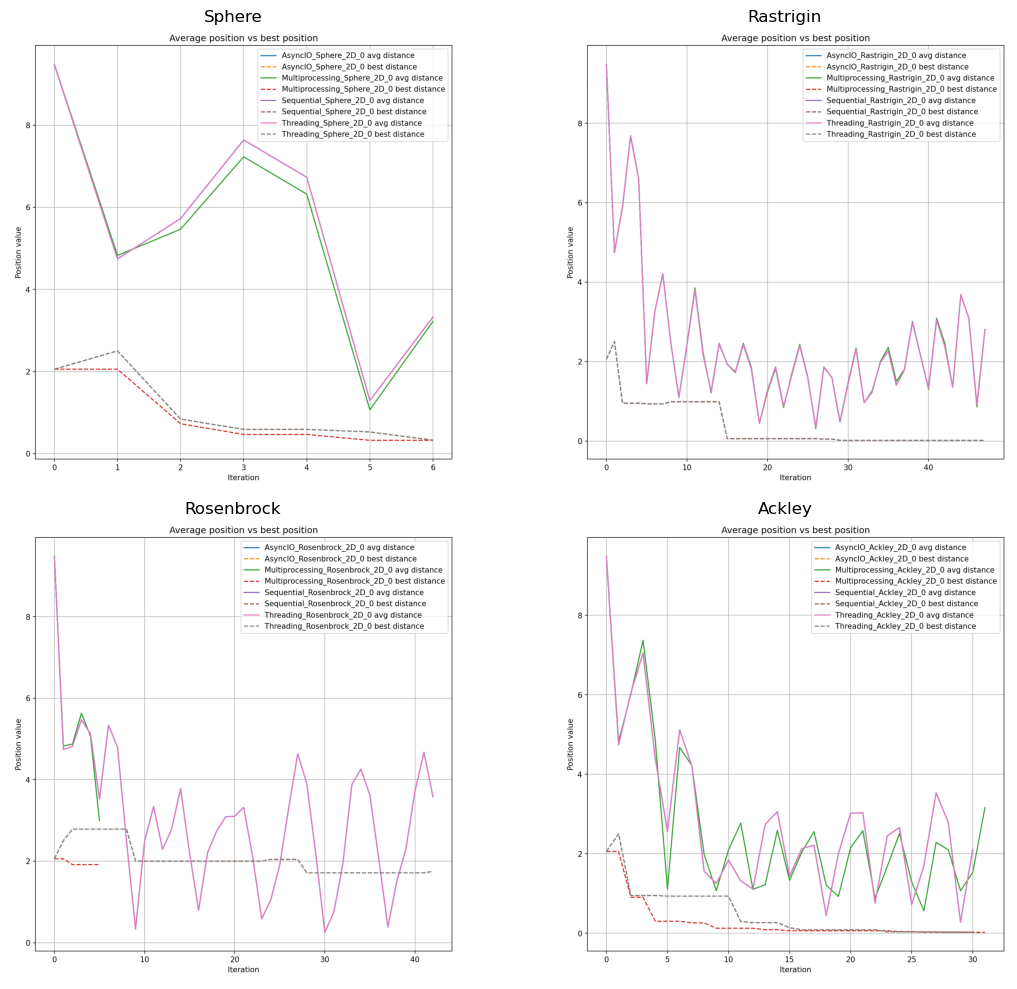

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
img1 = mpimg.imread("viz/0_Sphere_distance_2D.png")
img2 = mpimg.imread("viz/0_Rastrigin_distance_2D.png")
img3 = mpimg.imread("viz/0_Rosenbrock_distance_2D.png")
img4 = mpimg.imread("viz/0_Ackley_distance_2D.png")

# Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot images
axs[0, 0].imshow(img1)
axs[0, 0].set_title("Sphere")
axs[0, 0].axis("off")

axs[0, 1].imshow(img2)
axs[0, 1].set_title("Rastrigin")
axs[0, 1].axis("off")

axs[1, 0].imshow(img3)
axs[1, 0].set_title("Rosenbrock")
axs[1, 0].axis("off")

axs[1, 1].imshow(img4)
axs[1, 1].set_title("Ackley")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

The graphs above show a comparison of the trajectories, values, and average position among each of the functions. You can see how the swarm’s average values fluctuate as they converge toward the best value, while the best global value or position always improves without fluctuating. The only case in which the best position is seen to fluctuate is in the last set of graphs showing the average position; thus, even if it improves, whether the values are positive or negative will result in a very different average.

### 3.2. Experiment 2: Grid search for Rosenbrock benchmark function

En este segundo experimento se pondrá a prueba el grid search para encontrar los hiperparámetros óptimos para la función benchmark de Rosenbrock en dos dimensiones, mediante la estrategia de ejecución secuencial. Para ello se evaluarán los resultados de todas las combinaciones de los valores `{0.1, 0.5, 0.9}` de los hiperparámetros de the inertia term (`w`), the cognitive component (`c1`) and the social component (`C2`).

In [10]:
from experiments.exp2 import grid_search

grid_search(2, 3)

Running grid search with w=0.1, c1=0.1, c2=0.1...
Running grid search with w=0.1, c1=0.1, c2=0.5...
Running grid search with w=0.1, c1=0.1, c2=0.9...
Running grid search with w=0.1, c1=0.5, c2=0.1...
Running grid search with w=0.1, c1=0.5, c2=0.5...
Running grid search with w=0.1, c1=0.5, c2=0.9...
Running grid search with w=0.1, c1=0.9, c2=0.1...
Running grid search with w=0.1, c1=0.9, c2=0.5...
Running grid search with w=0.1, c1=0.9, c2=0.9...
Running grid search with w=0.5, c1=0.1, c2=0.1...
Running grid search with w=0.5, c1=0.1, c2=0.5...
Running grid search with w=0.5, c1=0.1, c2=0.9...
Running grid search with w=0.5, c1=0.5, c2=0.1...
Running grid search with w=0.5, c1=0.5, c2=0.5...
Running grid search with w=0.5, c1=0.5, c2=0.9...
Running grid search with w=0.5, c1=0.9, c2=0.1...
Running grid search with w=0.5, c1=0.9, c2=0.5...
Running grid search with w=0.5, c1=0.9, c2=0.9...
Running grid search with w=0.9, c1=0.1, c2=0.1...
Running grid search with w=0.9, c1=0.1, c2=0.5...


[19, 23, 16, 2, 14]

The grid search results clearly show that the PSO hyperparameters have a significant impact on both convergence quality and execution time when optimizing the two-dimensional Rosenbrock Function. Although all tested configurations were able to approach the global minimum near the point `(1, 1)`, the quality and speed of convergence varied considerably depending on the balance between inertia (`w`), cognitive influence (`c1`), and social influence (`c2`).

The best overall configuration was `w = 0.9`, `c1 = 0.1`, and `c2 = 0.5`, achieving a best value of `0.0033s`. This suggests that, for the Rosenbrock function, maintaining a relatively high inertia term while giving greater importance to the swarm’s collective knowledge leads to better convergence. A high inertia value allows particles to preserve momentum and explore the curved valley characteristic of the Rosenbrock landscape more effectively, while a moderate social component helps guide the swarm toward promising regions without causing premature convergence.

The results also indicate that configurations with high social influence (`c2 = 0.9`) generally performed well. Several of the top-performing combinations include strong social cooperation, such as (`w=0.9`, `c1=0.5`, `c2=0.9`) and (`w=0.1`, `c1=0.1`, `c2=0.9`). This behavior is consistent with the nature of the Rosenbrock function, where coordinated swarm movement can help particles navigate the narrow curved valley toward the optimum.

In contrast, configurations with low social influence and excessively high cognitive influence tended to perform worse. For example, the combination (`w=0.5`, `c1=0.9`, `c2=0.1`) produced the worst result (`0.0538s`) and also required the longest execution time (`2.8916 s`). This suggests that particles relying too heavily on their own personal experience may struggle to coordinate effectively, causing slower convergence and more unstable exploration.

Another important observation is that the best fitness value does not always correspond to the shortest execution time. Some parameter combinations converged very quickly but reached suboptimal solutions, while others required longer runtimes to achieve better accuracy. This demonstrates the classical trade-off in optimization algorithms between convergence speed and solution quality.

Overall, the experiment demonstrates that PSO performance is highly sensitive to hyperparameter selection. The grid search successfully identified parameter combinations capable of significantly improving convergence on the Rosenbrock benchmark, highlighting the usefulness of systematic hyperparameter tuning in swarm-based optimization algorithms.

### 3.3. Experiment 3: Optimization of the Industrialized Case

For this final experiment, the same function is used as in Experiment 1. It is used to evaluate the performance of the four parallelization versions using the objective function of the industrial-scale case: hyperparameter optimization in a logistic regression model. To do this, a swarm of 30 particles and a maximum of 10 iterations are used, traversing a three-dimensional space to optimize the regularization strength (C), the solver tolerance (tol), and the maximum number of training iterations (max_iter).

In [1]:
from experiments.exp1 import compare
compare(dimensions=3, function_choice=5)

+-----------------+----------------------+------------+--------------------+
|      Method     |    Best Position     | Best Value | Execution Time (s) |
+-----------------+----------------------+------------+--------------------+
|    Sequential   | [55.1465, 50.0, 0.1] |   0.0965   |       0.5237       |
|    Threading    | [55.1465, 50.0, 0.1] |   0.0965   |       5.8196       |
| Multiprocessing | [54.7912, 50.0, 0.1] |   0.0965   |       2.3512       |
|     AsyncIO     | [55.1465, 50.0, 0.1] |   0.0965   |       2.6975       |
+-----------------+----------------------+------------+--------------------+


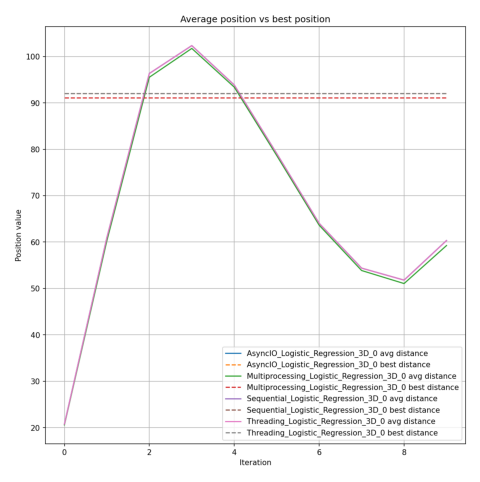

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from viz.charts import plot

plot()

# Load images
img = mpimg.imread("viz/0_Logistic_Regression_distance_2D.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")

plt.show()

The results of this final experiment show that all four execution strategies were capable of reaching practically the same solution quality when optimizing the hyperparameters of the Logistic Regression model. The best value obtained by all methods was `0.0965`, which indicates that the PSO implementation behaves consistently across the different parallelization approaches even in a more realistic optimization scenario. Furthermore, the best hyperparameter configuration converged toward very similar values in all strategies, especially for `max_iter = 50` and `tol = 0.1`, suggesting that the search space contains a stable optimum region for this problem.

From the performance perspective, the sequential implementation again achieved the best execution time (`0.5237 s`). This confirms the conclusions observed in previous experiments: for relatively lightweight objective functions and small swarm sizes, the overhead introduced by parallelization is greater than the computational cost of the optimization itself. Since the logistic regression model used here is intentionally simple and trained on a relatively small dataset, the evaluation of each particle is computationally inexpensive. As a result, the cost of thread management, coroutine scheduling, process synchronization, and inter-process communication dominates the total runtime.

The threading implementation produced the slowest execution (`5.8196 s`). This behavior is mainly explained by the Global Interpreter Lock (GIL) in Python, which prevents true parallel execution of CPU-bound tasks. Although multiple threads are created, the particle evaluations are still executed sequentially at the interpreter level, while also introducing additional context-switching overhead.

The multiprocessing version improved significantly compared to threading (`2.3512 s`) because it can exploit multiple CPU cores without being constrained by the GIL. However, its execution time remained considerably slower than the sequential version. This is due to the overhead associated with process creation, particle serialization (pickling), and inter-process communication (IPC). Since each particle evaluation is computationally small, the multiprocessing overhead outweighs the potential benefits of true parallelism.

The AsyncIO implementation achieved intermediate performance (`2.6975 s`). Its results were identical to the sequential version because both strategies preserve the same deterministic seed behavior and execution order. However, AsyncIO introduces additional coroutine scheduling overhead. In this implementation, each particle task voluntarily yields control using await `asyncio.sleep(0)`, enabling cooperative multitasking. Since the workload is CPU-bound rather than I/O-bound, AsyncIO does not provide a real performance advantage, although it still remains notably more efficient than threading.

The distance graph further reinforces these conclusions. The average particle position remains relatively far from the global best position during most iterations, while the best particle rapidly stabilizes around the optimum region. This indicates that the swarm maintains exploration diversity even after finding good solutions, which is beneficial for avoiding premature convergence. Additionally, the trajectories of all methods are nearly identical, confirming that the different parallelization strategies preserve the same optimization dynamics despite their differences in execution models and runtime overhead.

## 4. Conclusions

The experiments carried out throughout this project demonstrate that the Particle Swarm Optimization (PSO) algorithm is a flexible and effective optimization technique capable of solving both classical mathematical benchmark functions and practical machine learning problems. The algorithm successfully converged toward near-optimal solutions in all evaluated objective functions, including complex multimodal landscapes such as Rastrigin and Ackley, as well as the industrial-scale case based on logistic regression hyperparameter optimization. Additionally, the implementation of a grid search procedure proved that PSO performance is highly dependent on the choice of hyperparameters, highlighting the importance of properly balancing exploration and exploitation through the inertia, cognitive, and social components.

Regarding parallelization strategies, the results show that parallel execution does not always guarantee better performance. In the evaluated environment — a virtual machine with limited computational resources — the sequential implementation consistently achieved the best execution times for most experiments. Threading showed the worst performance due to Python’s Global Interpreter Lock (GIL), while multiprocessing introduced considerable overhead caused by process creation, pickling, and inter-process communication. The AsyncIO implementation achieved results very similar to the sequential version, demonstrating that cooperative concurrency can be efficient when synchronization overhead is minimized, although it does not provide significant benefits for CPU-bound workloads. Overall, the project illustrates both the strengths of PSO as an optimization method and the practical limitations of different parallelization strategies depending on the nature of the problem and the execution environment.